# Principal Component Analysis with Cancer Data

In [204]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [205]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [206]:
data  = pd.read_csv("breast-cancer-wisconsin-data.csv")
data.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [207]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [208]:
data.head(2).T

,0,1
ID,1000025,1002945
ClumpThickness,5,5
Cell Size,1,4
Cell Shape,1,4
Marginal Adhesion,1,5
Single Epithelial Cell Size,2,7
Bare Nuclei,1,10
Normal Nucleoli,3,3
Bland Chromatin,1,2
Mitoses,1,1


In [209]:
data.dtypes

ID                              int64
ClumpThickness                  int64
Cell Size                       int64
Cell Shape                      int64
Marginal Adhesion               int64
Single Epithelial Cell Size     int64
Bare Nuclei                    object
Normal Nucleoli                 int64
Bland Chromatin                 int64
Mitoses                         int64
Class                           int64
dtype: object

In [210]:
data.shape

(699, 11)

# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [211]:
# We could see "?" values in column, this should be removed from data set
data.isnull().values.any()
print("there are no NAN values in the data")
# Check for missing value in any other column

there are no NAN values in the data


In [212]:
# No missing values found. So let us try to remove ? from bare nuclei column
print(data.loc[data["Bare Nuclei"] == '?',["Bare Nuclei"]].count())
# Get count of rows having ?


Bare Nuclei    16
dtype: int64


In [213]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

#Replace ? to NAN then replace to median
data = data.replace('?', np.nan)
data = data.apply(lambda x: x.fillna(x.median()),axis=0)


# converting the hp column from object / string type to float
data['Bare Nuclei'] = data['Bare Nuclei'].astype('float64')  


# Q4. Perform bi variate analysis including correlation & pairplots. 


In [214]:
# Check for correlation of variable
#Create correlation matrix
corr_matrix = data.corr().abs()
corr_matrix
# Select upper triangle of correlation matrix
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(np.bool))
upper
# Find features with correlation greater than 0.7
to_corr = [column for column in upper.columns if any(upper[column] >= 0.7)]
print(to_corr)
print("'Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Normal Nucleoli', 'Bland Chromatin', 'Class' have Coefficient greater than 0.7")

['Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Bare Nuclei', 'Normal Nucleoli', 'Bland Chromatin', 'Class']
'Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Normal Nucleoli', 'Bland Chromatin', 'Class' have Coefficient greater than 0.7


'Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Normal Nucleoli', 'Bland Chromatin', 'Class' have Coefficient greater than 0.7


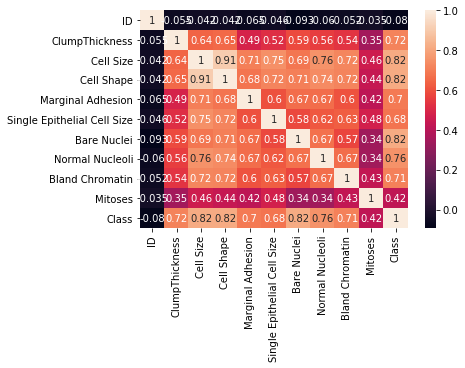

In [215]:
sns.heatmap( data.corr(), annot=True)
print("'Cell Shape', 'Marginal Adhesion', 'Single Epithelial Cell Size', 'Normal Nucleoli', 'Bland Chromatin', 'Class' have Coefficient greater than 0.7")

In [216]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

C:\Users\sush\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


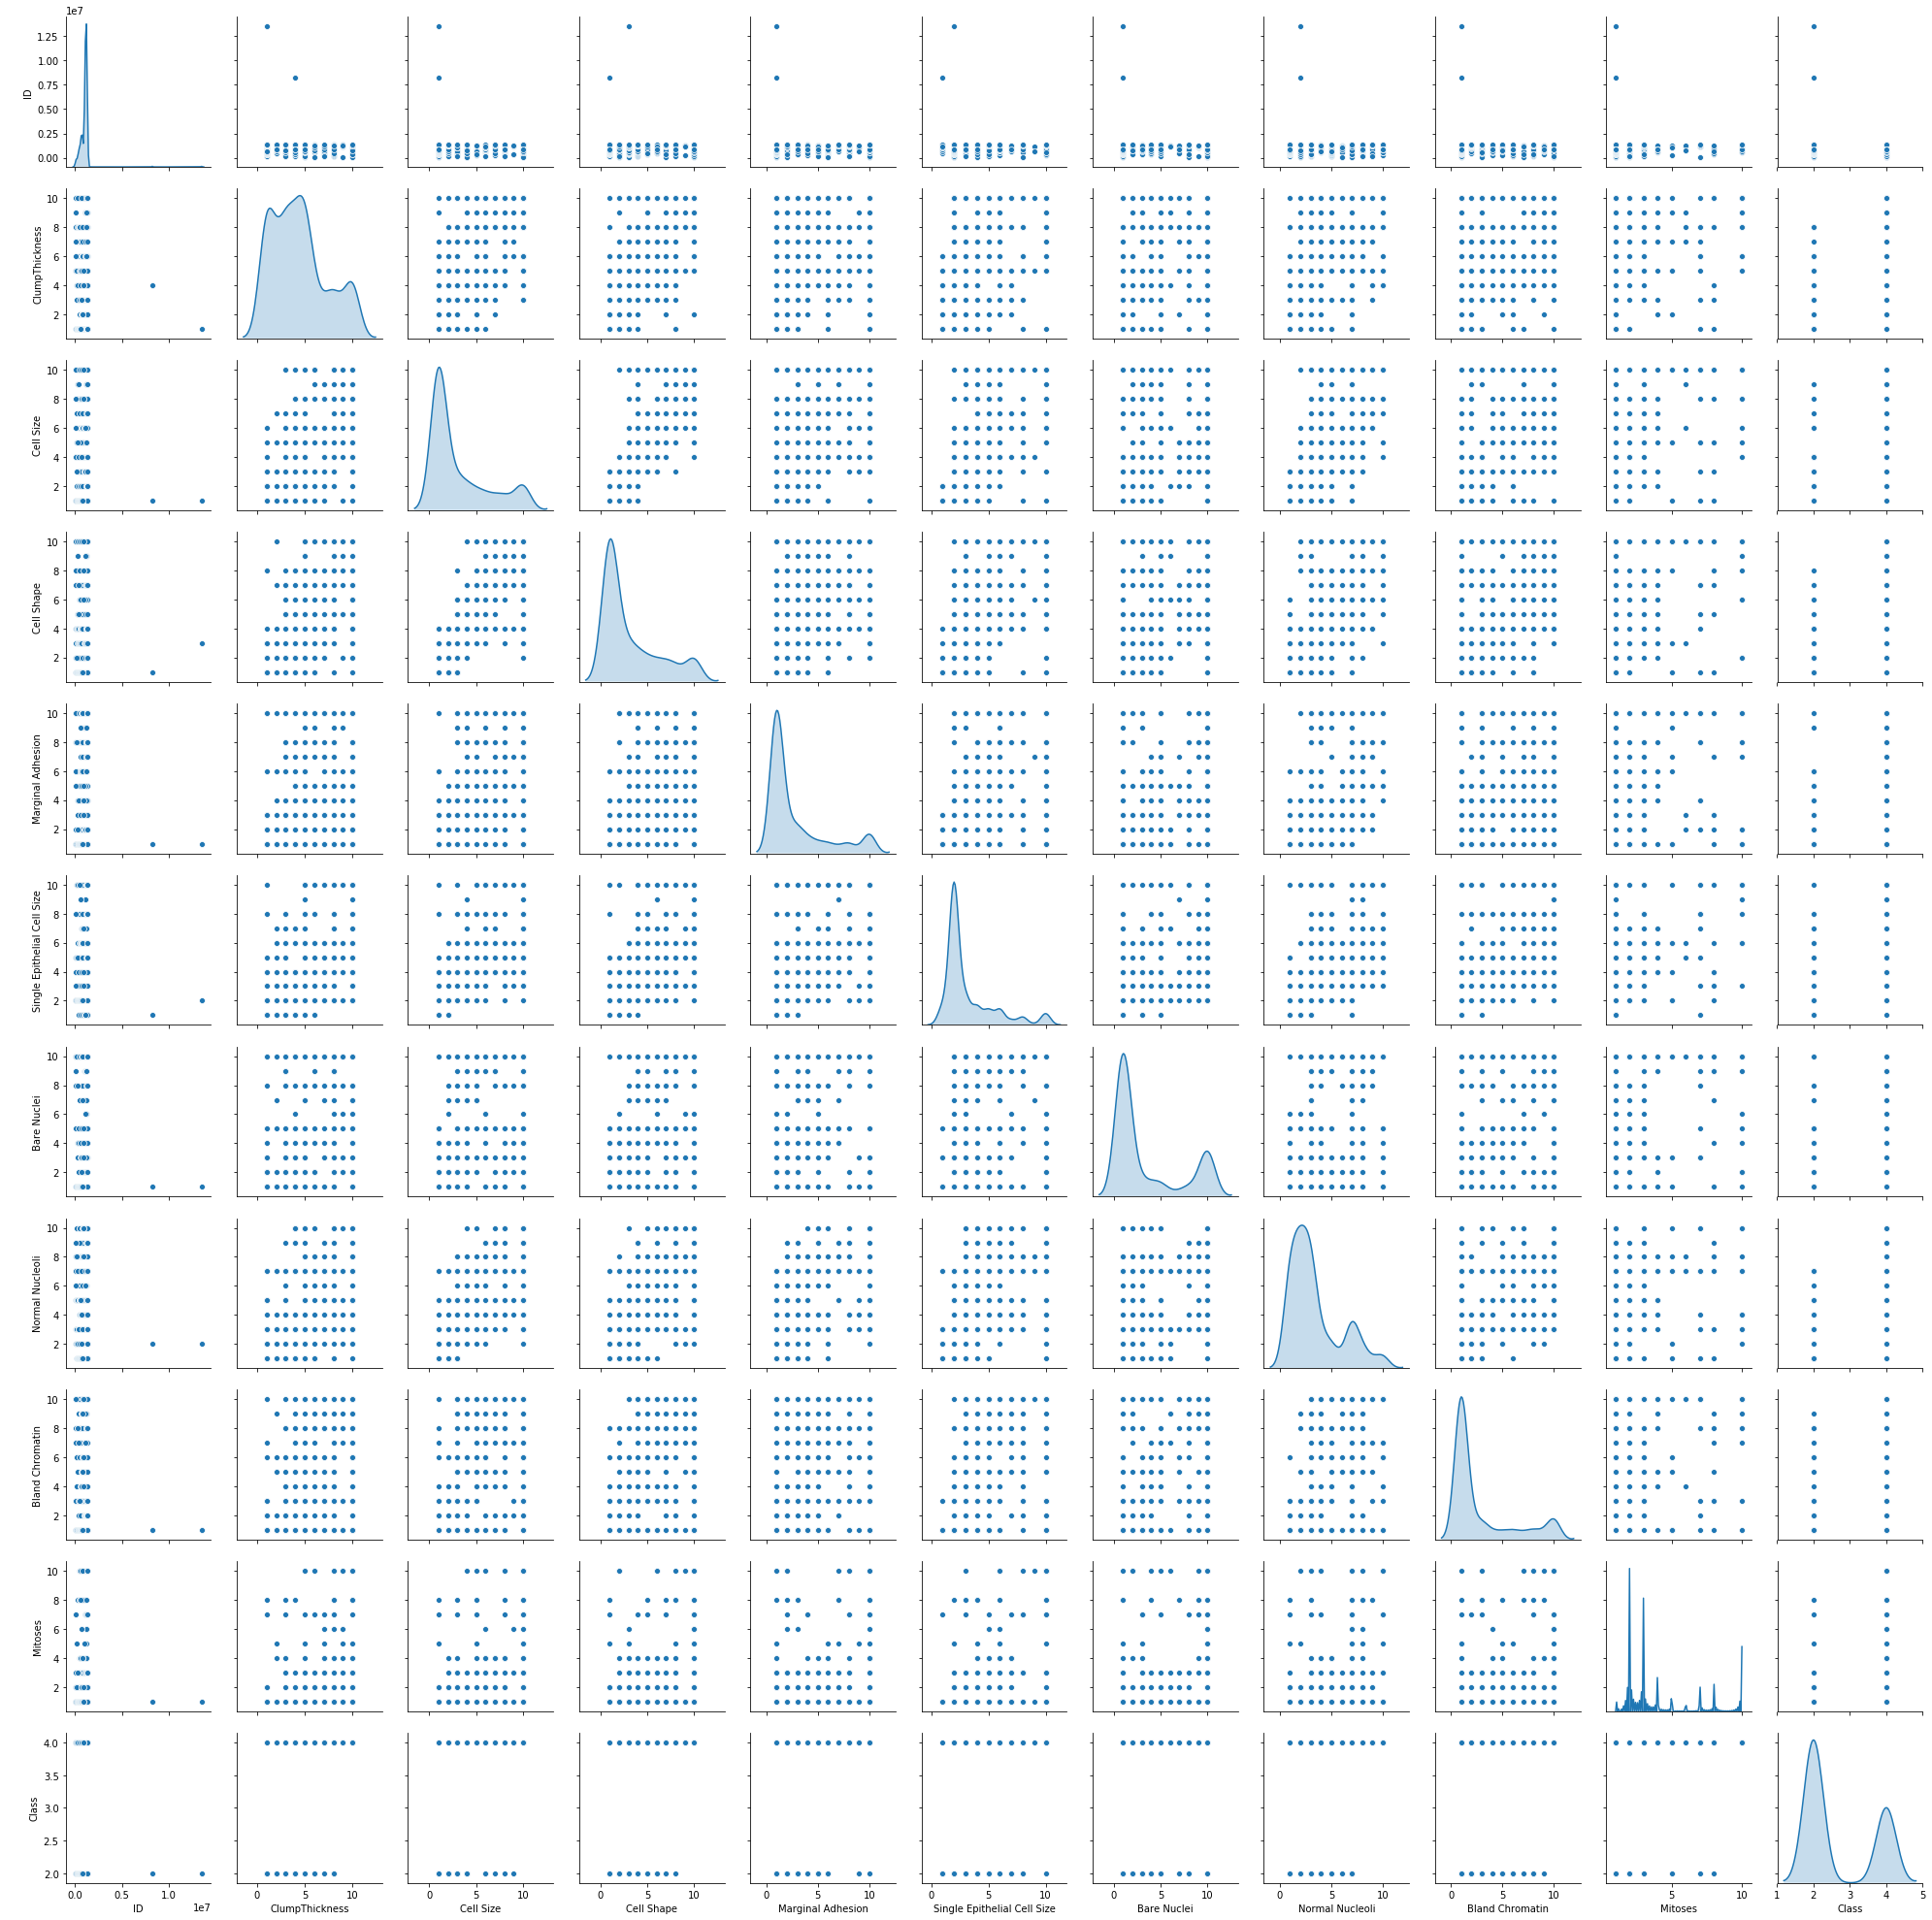

In [217]:
#Let us check for pair plots
import seaborn as sns
sns.pairplot(data,diag_kind='kde')

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

Plotting for column Bare Nuclei


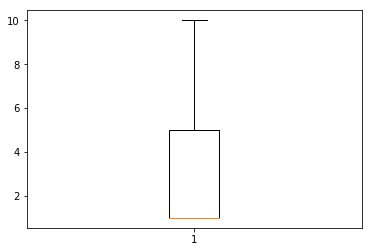

Plotting for column Bland Chromatin


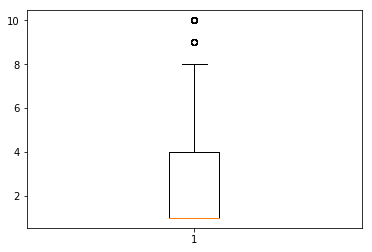

Plotting for column Cell Shape


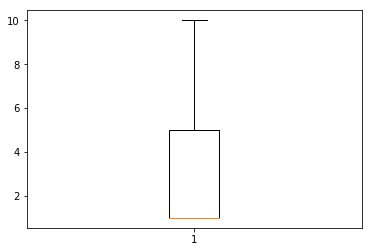

Plotting for column Cell Size


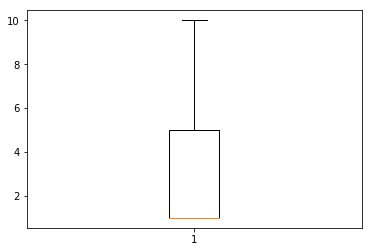

Plotting for column ClumpThickness


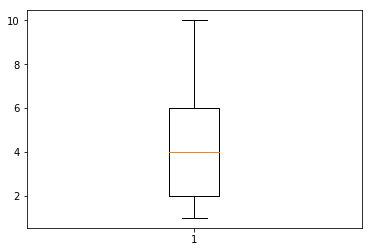

Plotting for column Marginal Adhesion


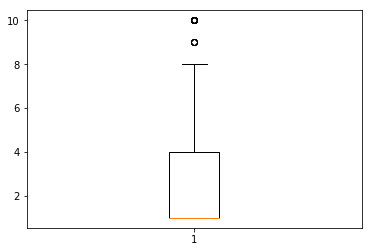

Plotting for column Mitoses


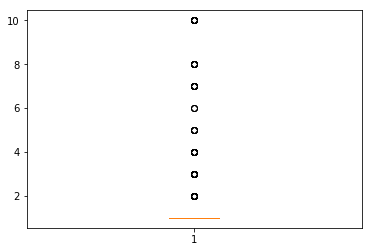

Plotting for column Normal Nucleoli


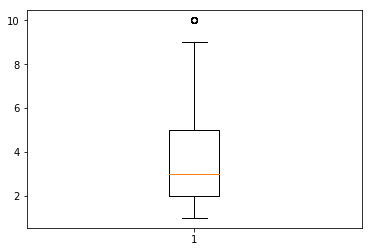

Plotting for column Single Epithelial Cell Size


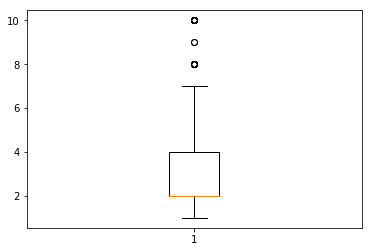

Although i am seeing outliers i am not treating them as in case of cancer patients the turning values might be the outlier


In [238]:
# for outlier 
for col in data.columns.difference(['Class']):
 plt.boxplot(data[col])
 print("Plotting for column",format(col))
 plt.show()
print("Although i am seeing outliers i am not treating them as in case of cancer patients the turning values might be the outlier")

In [ ]:
pd.crosstab(data['Marginal Adhesion'], data['Class'])

data['Marginal Adhesion']=np.where(data['Marginal Adhesion']>4,4,data['Marginal Adhesion'])
data['Single Epithelial Cell Size']=np.where(data['Single Epithelial Cell Size']>4,4,data['Single Epithelial Cell Size'])
data['Normal Nucleoli']=np.where(data['Normal Nucleoli']>5,5,data['Normal Nucleoli'])
data['Bland Chromatin']=np.where(data['Bland Chromatin']>4,4,data['Bland Chromatin'])
data['Mitoses']=np.where(data['Mitoses']>1,1,c_df['Mitoses'])

data.boxplot(column=['ClumpThickness','Cell Size','Cell Shape','Marginal Adhesion','Single Epithelial Cell Size',
                      'Bare Nuclei','Normal Nucleoli','Bland Chromatin','Mitoses'], rot=90, fontsize=15)

In [219]:
# Dropping the ID column
data = data.drop('ID', axis=1)
data.head(2).T

,0,1
ClumpThickness,5.0,5.0
Cell Size,1.0,4.0
Cell Shape,1.0,4.0
Marginal Adhesion,1.0,5.0
Single Epithelial Cell Size,2.0,7.0
Bare Nuclei,1.0,10.0
Normal Nucleoli,3.0,3.0
Bland Chromatin,1.0,2.0
Mitoses,1.0,1.0
Class,2.0,2.0


In [220]:
X = data[data.columns[1:-1]]
y = data["Class"]

C:\Users\sush\Anaconda3\lib\site-packages\sklearn\preprocessing\data.py:625: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
C:\Users\sush\Anaconda3\lib\site-packages\sklearn\base.py:462: DataConversionWarning: Data with input dtype int64, float64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)
C:\Users\sush\Anaconda3\lib\site-packages\scipy\stats\stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval


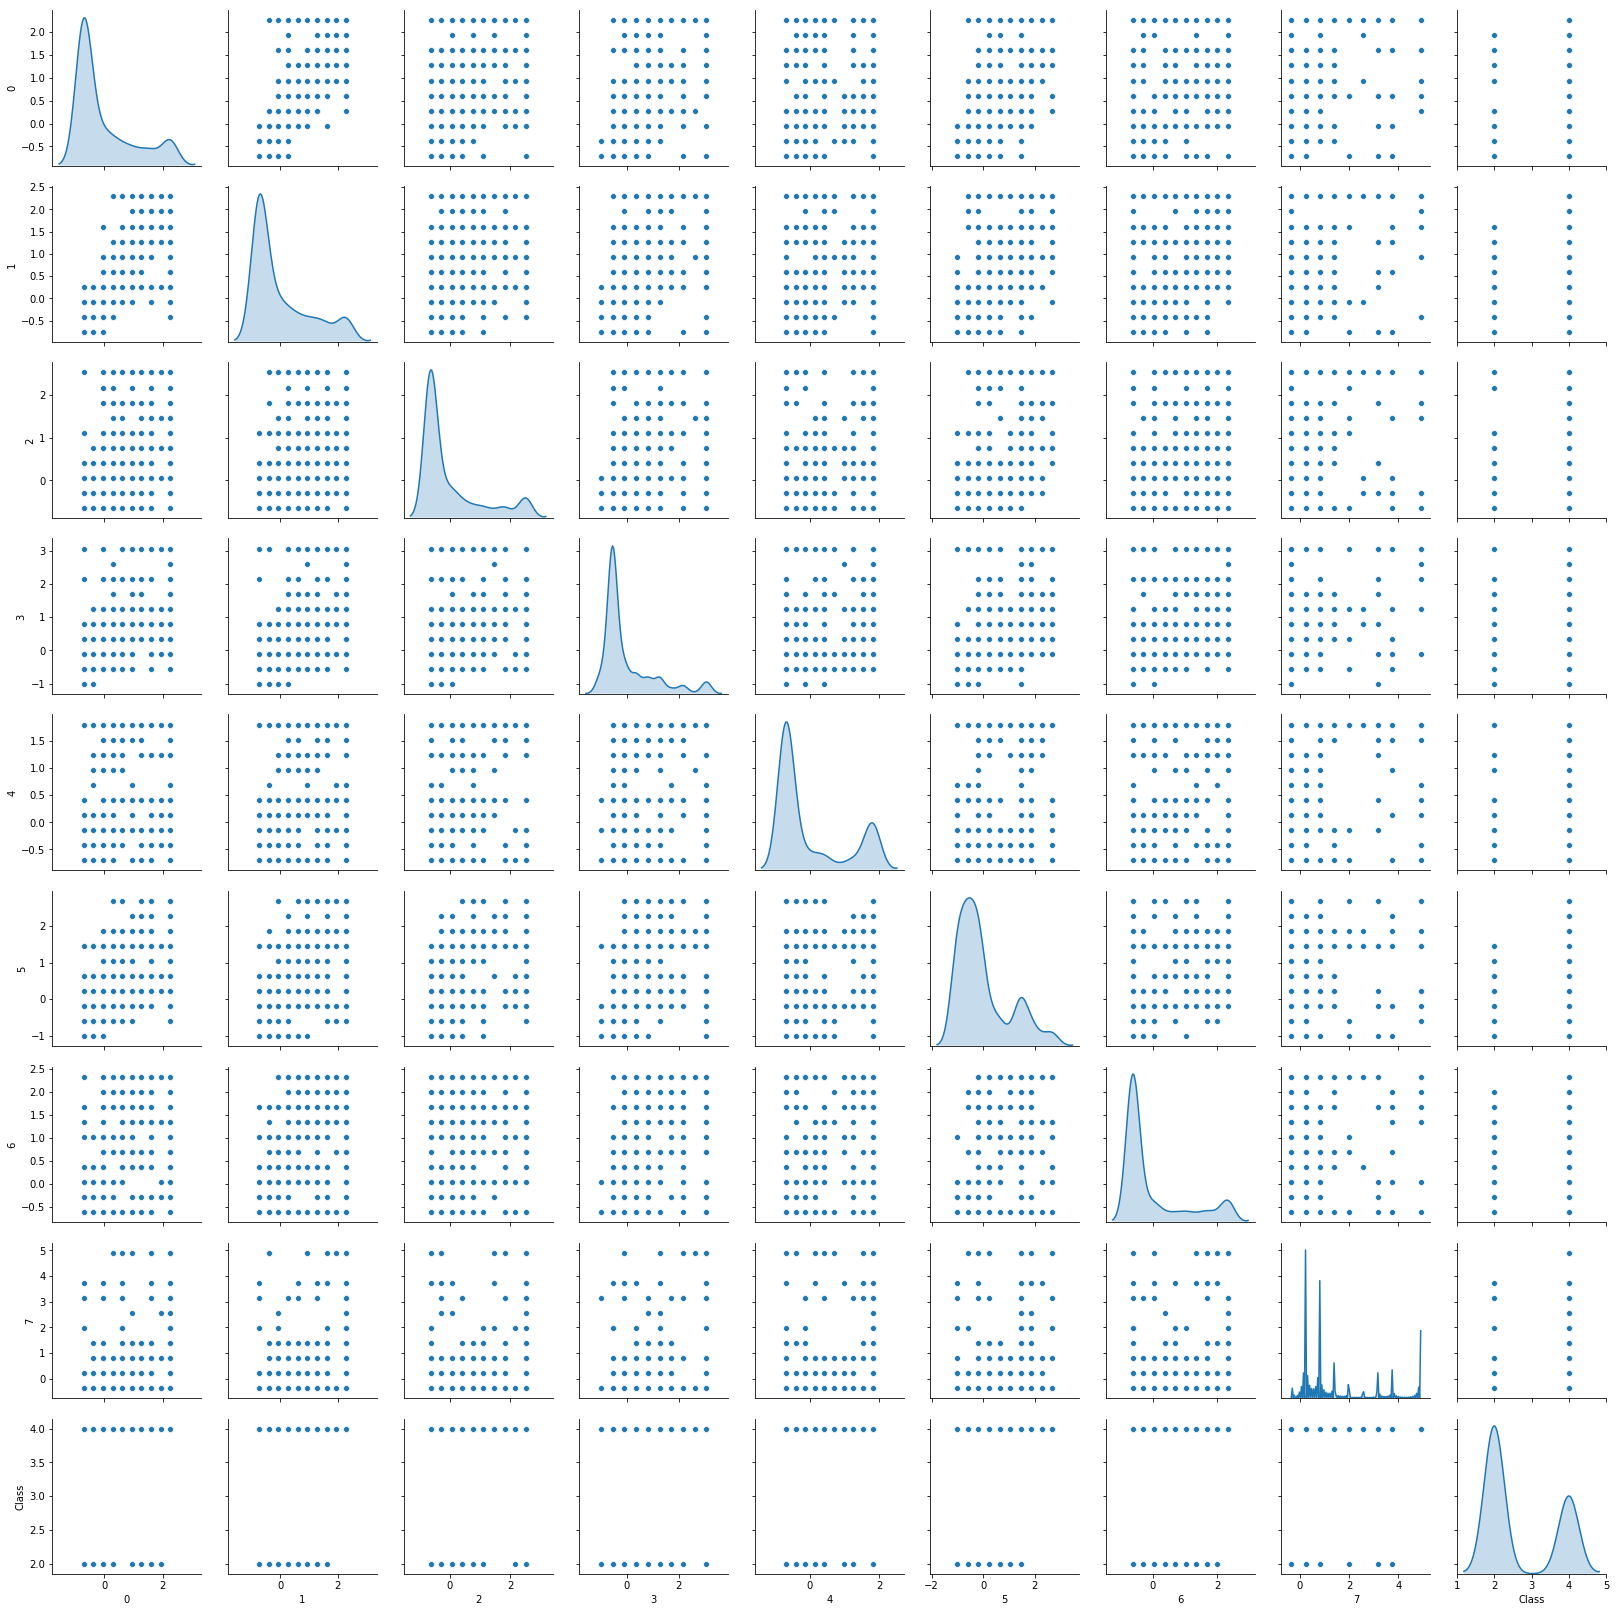

In [264]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
#Standardized the mean
sc = StandardScaler()
X_std =  sc.fit_transform(X)   

#Let us check it visually
Proj_data_df = pd.DataFrame(X_std)
Proj_data_mpg_df = Proj_data_df.join(y)
sns.pairplot(Proj_data_mpg_df, diag_kind='kde')

# Q6 Create a covariance matrix for identifying Principal components

In [267]:
# PCA
# Step 1 - Create covariance matrix
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00143266 0.90818117 0.70659267 0.75287621 0.68765657 0.75680368
  0.72390044 0.4593503 ]
 [0.90818117 1.00143266 0.68405782 0.72069948 0.70848734 0.73700282
  0.72047704 0.43953974]
 [0.70659267 0.68405782 1.00143266 0.60045809 0.66792658 0.66767051
  0.60421681 0.41823111]
 [0.75287621 0.72069948 0.60045809 1.00143266 0.5845377  0.61698451
  0.62978166 0.47978787]
 [0.68765657 0.70848734 0.66792658 0.5845377  1.00143266 0.67518063
  0.5756016  0.34288766]
 [0.75680368 0.73700282 0.66767051 0.61698451 0.67518063 1.00143266
  0.66683179 0.34466258]
 [0.72390044 0.72047704 0.60421681 0.62978166 0.5756016  0.66683179
  1.00143266 0.42894941]
 [0.4593503  0.43953974 0.41823111 0.47978787 0.34288766 0.34466258
  0.42894941 1.00143266]]


# Q7 Identify eigen values and eigen vector

In [225]:
# Step 2- Get eigen values and eigen vector

In [268]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-0.39847994 -0.062414   -0.73601628 -0.20398524 -0.14132791  0.43266205
  -0.21598654  0.01296432]
 [-0.39370776 -0.09340305  0.66494297 -0.18506849 -0.12668727  0.55098835
  -0.1426921   0.14096705]
 [-0.35272931 -0.08531517  0.04692692  0.5248911   0.12334922  0.09451857
   0.08350668 -0.7479762 ]
 [-0.35462838  0.14260532  0.0679272  -0.35935778 -0.63861856 -0.46940404
   0.18406897 -0.24102929]
 [-0.34696126 -0.25494788 -0.07379637  0.52742009 -0.18497738 -0.10368618
   0.41414996  0.56081545]
 [-0.36327475 -0.25577122  0.0587669   0.02887731  0.26700296 -0.50964666
  -0.6712839   0.1291229 ]
 [-0.35310871  0.00382172 -0.01896902 -0.43307607  0.65074018 -0.09716218
   0.50431126  0.01232102]
 [-0.24288322  0.91067748  0.00744054  0.23006578  0.10935296 -0.00323347
  -0.12514757  0.1762334 ]]

 Eigen Values 
%s [5.40438223 0.76982562 0.0889498  0.46721886 0.38250129 0.27328063
 0.2960949  0.32920798]


# Q8 Find variance and cumulative variance by each eigen vector

In [269]:
eigen_pairs = [(np.abs(eig_vals[i]), eig_vecs[ :, i]) for i in range(len(eig_vals))]

In [270]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
print("Variance Explained",var_exp)
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Variance Explained [67.45813304359058, 9.609053692925643, 5.831880626929563, 4.774425970121564, 4.109212646975164, 3.695891256993597, 3.4111209277911794, 1.1102818346727228]
Cumulative Variance Explained [ 67.45813304  77.06718674  82.89906736  87.67349333  91.78270598
  95.47859724  98.88971817 100.        ]


# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [282]:
from sklearn.decomposition import PCA
pca = PCA(n_components=8)
pca.fit(X_std)
X_pca = pca.transform(X_std)
X_pca

array([[-1.59302450e+00, -5.66355253e-03,  3.62170817e-02, ...,
         3.26203782e-01,  2.90944961e-01, -3.09500641e-03],
       [ 1.47103850e+00, -5.91494315e-01, -6.69522596e-01, ...,
        -1.04526871e+00,  5.26546813e-01,  1.97629721e-02],
       [-1.49716130e+00, -7.61040437e-02, -1.09505762e-01, ...,
         2.11776759e-01,  3.19592799e-01,  1.72944662e-02],
       ...,
       [ 3.94517693e+00, -3.33593707e-01,  2.43563360e+00, ...,
         6.55889174e-01, -2.69841221e-01, -6.04429526e-02],
       [ 2.42552970e+00, -1.27129792e+00,  6.16107000e-01, ...,
         1.65014017e+00,  1.92099779e-01,  4.10396145e-01],
       [ 2.83898668e+00, -1.37259751e+00,  2.89617700e-01, ...,
         1.84989467e+00, -3.49839487e-02, -7.65973628e-02]])

In [283]:
X_pca.shape

(699, 8)

In [284]:
pca.components_

array([[ 0.39847994,  0.39370776,  0.35272931,  0.35462838,  0.34696126,
         0.36327475,  0.35310871,  0.24288322],
       [-0.062414  , -0.09340305, -0.08531517,  0.14260532, -0.25494788,
        -0.25577122,  0.00382172,  0.91067748],
       [ 0.20398524,  0.18506849, -0.5248911 ,  0.35935778, -0.52742009,
        -0.02887731,  0.43307607, -0.23006578],
       [ 0.14132791,  0.12668727, -0.12334922,  0.63861856,  0.18497738,
        -0.26700296, -0.65074018, -0.10935296],
       [-0.01296432, -0.14096705,  0.7479762 ,  0.24102929, -0.56081545,
        -0.1291229 , -0.01232102, -0.1762334 ],
       [ 0.21598654,  0.1426921 , -0.08350668, -0.18406897, -0.41414996,
         0.6712839 , -0.50431126,  0.12514757],
       [-0.43266205, -0.55098835, -0.09451857,  0.46940404,  0.10368618,
         0.50964666,  0.09716218,  0.00323347],
       [ 0.73601628, -0.66494297, -0.04692692, -0.0679272 ,  0.07379637,
        -0.0587669 ,  0.01896902, -0.00744054]])

In [285]:
pca.explained_variance_

array([5.40438223, 0.76982562, 0.46721886, 0.38250129, 0.32920798,
       0.2960949 , 0.27328063, 0.0889498 ])

In [286]:
pca.explained_variance_ratio_

array([0.67458133, 0.09609054, 0.05831881, 0.04774426, 0.04109213,
       0.03695891, 0.03411121, 0.01110282])

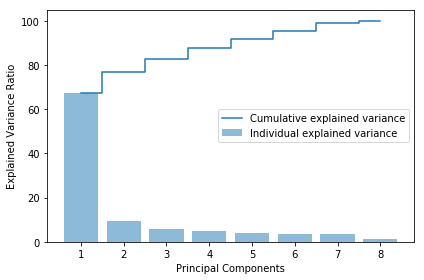

In [287]:
plt.figure(figsize=(6 , 4))
plt.bar(range(1,9), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(1,9), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q10 Find correlation between components and features

In [288]:
pca_df = pd.DataFrame(X_pca)
pca_df.head(10)

,0,1,2,3,4,5,6,7
0,-1.593025,-0.005664,0.036217,-0.109303,-0.015644,0.326204,0.290945,-0.003095
1,1.471039,-0.591494,-0.669523,1.674580,0.023823,-1.045269,0.526547,0.019763
2,-1.497161,-0.076104,-0.109506,-0.058195,-0.170594,0.211777,0.319593,0.017294
3,1.391903,-0.508459,1.517497,-0.323856,-0.757822,-0.259721,-1.511874,0.186974
4,-1.345785,-0.065464,-0.331697,-0.195763,0.508637,0.267671,0.224694,-0.035988
5,4.894536,-1.616268,0.192402,0.355174,0.161790,0.406853,-0.123184,-0.038374
6,-0.730256,-0.639628,-1.275289,0.350669,-1.410192,-0.703639,0.548776,0.180410
7,-1.460453,-0.037115,0.098534,-0.066645,-0.063112,0.374252,0.105414,-0.226998
8,-1.324332,2.329729,-0.477037,-0.145366,-0.320975,0.067293,-0.119831,0.027776
9,-1.611434,0.078838,0.114965,0.046624,0.033097,0.121538,-0.060107,0.262397


In [289]:
pca_df.corr()

,0,1,2,3,4,5,6,7
0,1.000000e+00,-9.825534e-17,5.118967e-16,-2.791146e-16,-5.818050e-16,-9.053131e-17,-4.239897e-16,-1.949914e-15
1,-9.825534e-17,1.000000e+00,1.567422e-16,-5.642517e-17,-1.261445e-16,-1.292632e-16,-7.694184e-17,-5.801791e-16
2,5.118967e-16,1.567422e-16,1.000000e+00,2.142282e-16,8.002286e-17,7.483714e-17,-1.003567e-16,-7.345857e-16
3,-2.791146e-16,-5.642517e-17,2.142282e-16,1.000000e+00,-1.879774e-17,-1.654211e-17,-1.942492e-16,-4.835700e-16
4,-5.818050e-16,-1.261445e-16,8.002286e-17,-1.879774e-17,1.000000e+00,-5.158212e-17,2.266668e-16,1.742223e-16
5,-9.053131e-17,-1.292632e-16,7.483714e-17,-1.654211e-17,-5.158212e-17,1.000000e+00,-4.635424e-16,-4.689740e-16
6,-4.239897e-16,-7.694184e-17,-1.003567e-16,-1.942492e-16,2.266668e-16,-4.635424e-16,1.000000e+00,5.213412e-16
7,-1.949914e-15,-5.801791e-16,-7.345857e-16,-4.835700e-16,1.742223e-16,-4.689740e-16,5.213412e-16,1.000000e+00


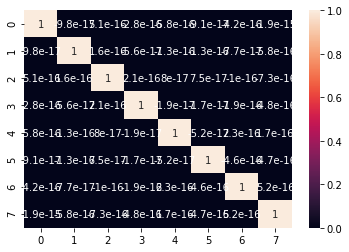

In [290]:
sns.heatmap( pca_df.corr(), annot=True)

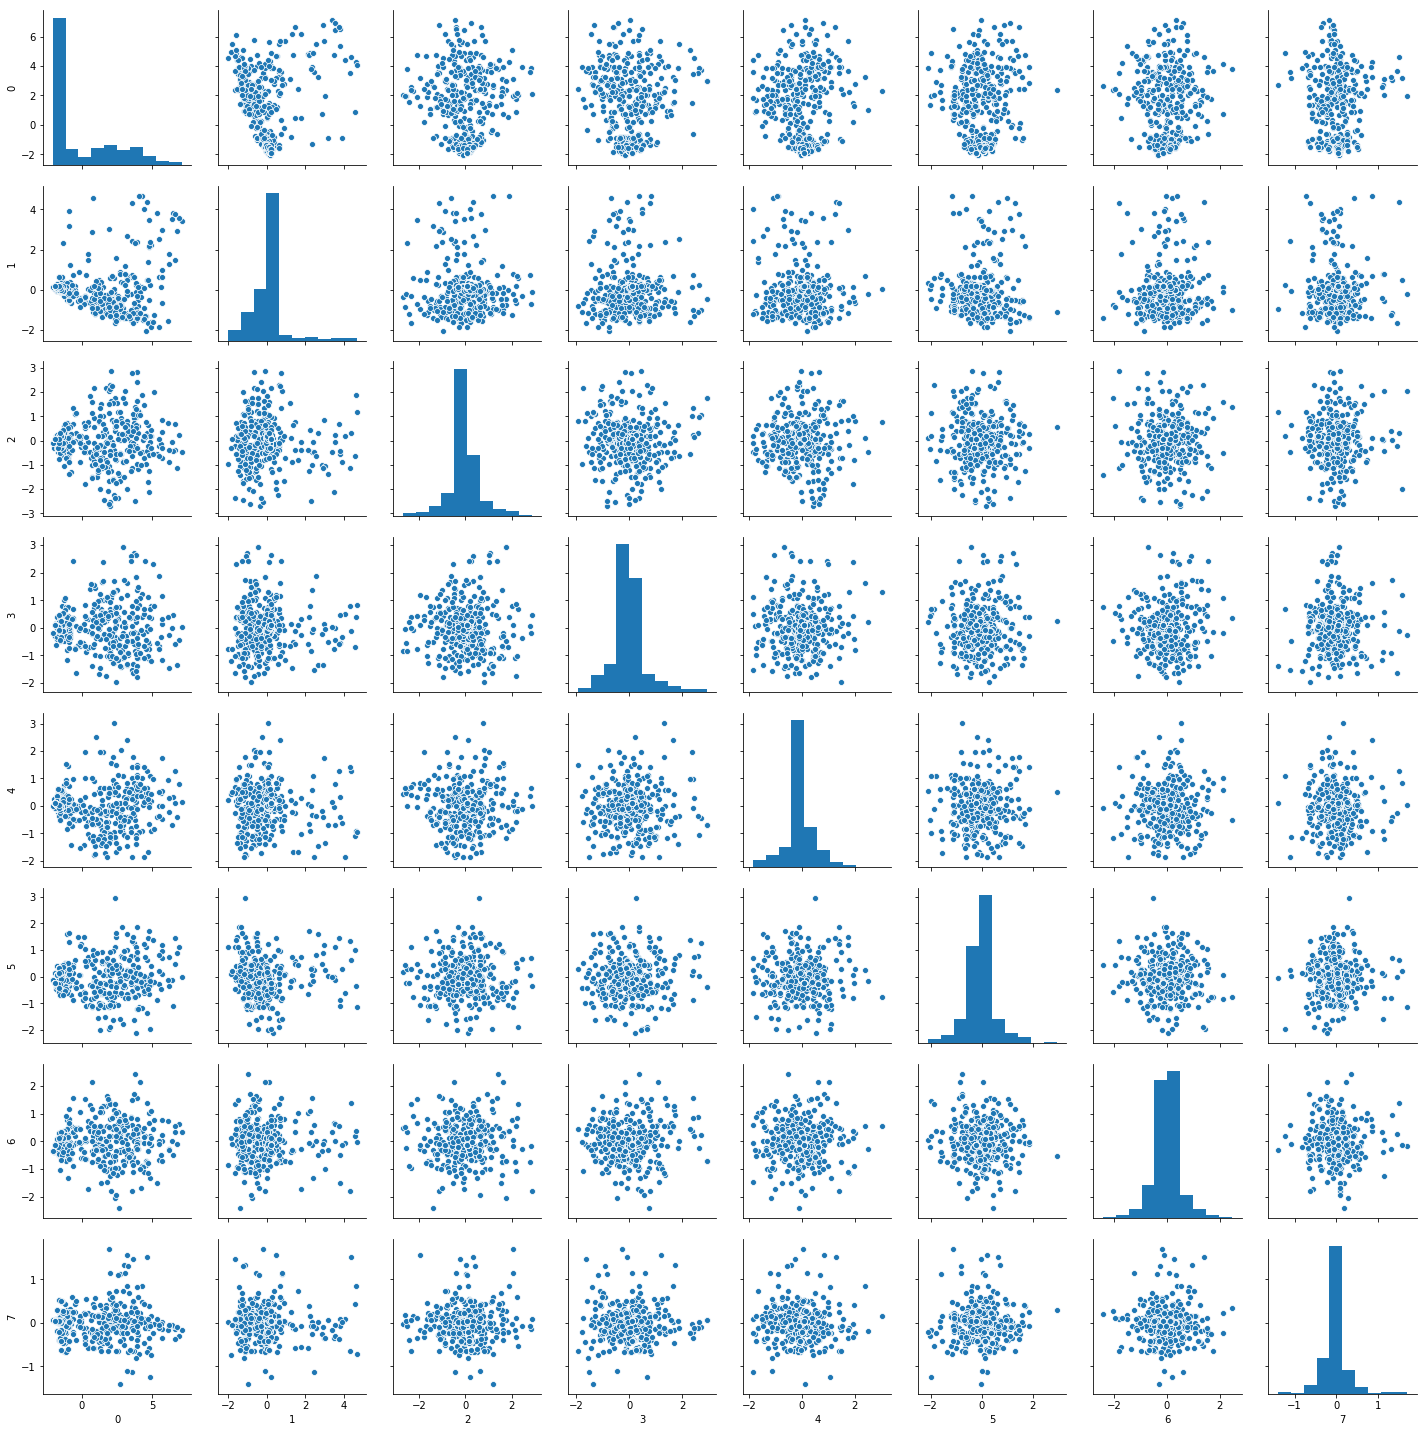

In [291]:
import seaborn as sns
sns.pairplot(pca_df)